# 06- Key Field Extraction (FUNSD and SROIE)

### 1: Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


### 2: Seeds and config

In [ ]:
#Setting fixed seeds to ensure reprodcible results
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Seed: {SEED} | Device: {DEVICE}")

Seed: 42 | Device: cuda


### 3: Install required packages

In [ ]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn tqdm --quiet
!pip install seqeval --quiet
print("All packages are installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All packages are installed.


### 4: Import libraries

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizerFast,
                          DistilBertForTokenClassification)
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import re
import os
import time
import requests
import zipfile
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score

print("All imports are fine.")
print(f"Device: {DEVICE}")

All imports OK.
Device: cuda


### 5: Download FUNSD dataset

In [ ]:
import os
import requests
import zipfile

FUNSD_DIR = f"{BASE}/data/funsd"
os.makedirs(FUNSD_DIR, exist_ok=True)

funsd_url = "https://guillaumejaume.github.io/FUNSD/dataset.zip"

zip_path = f"{FUNSD_DIR}/funsd.zip"

if not os.path.exists(f"{FUNSD_DIR}/dataset"):
    print("Downloading FUNSD dataset")
    response = requests.get(funsd_url)
    with open(zip_path, 'wb') as f:
        f.write(response.content)

    print("Extracting")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(FUNSD_DIR)
    print("FUNSD downloaded and extracted.")
else:
    print("FUNSD already exists on Drive.")

#Listing the files
train_path = f"{FUNSD_DIR}/dataset/training_data/annotations"
test_path  = f"{FUNSD_DIR}/dataset/testing_data/annotations"
print(f"Train files: {len(os.listdir(train_path))}")
print(f"Test files : {len(os.listdir(test_path))}")

Extracting...
FUNSD downloaded and extracted.
Train files: 149
Test files : 50


### 6: Load FUNSD data

In [ ]:
import json
import os

def load_funsd(data_dir):
    samples = []
    ann_dir = os.path.join(data_dir, "annotations")

    for fname in sorted(os.listdir(ann_dir)):
        if not fname.endswith('.json'):
            continue
        with open(os.path.join(ann_dir, fname)) as f:
            data = json.load(f)

        words  = []
        labels = []

        for item in data['form']:
            label = item['label'].upper()
            for word in item['words']:
                words.append(word['text'])
                labels.append(label)

        if words:
            samples.append({'words': words, 'labels': labels})

    return samples


funsd_train = load_funsd(f"{FUNSD_DIR}/dataset/training_data")
funsd_test  = load_funsd(f"{FUNSD_DIR}/dataset/testing_data")

#Getting the unique labels
all_labels = set()
for s in funsd_train + funsd_test:
    all_labels.update(s['labels'])

FUNSD_LABELS = sorted(all_labels)
print(f"Train samples : {len(funsd_train)}")
print(f"Test samples  : {len(funsd_test)}")
print(f"Unique labels : {FUNSD_LABELS}")

Train samples : 149
Test samples  : 50
Unique labels : ['ANSWER', 'HEADER', 'OTHER', 'QUESTION']


### 7:Rule-based baseline for FUNSD

In [ ]:
#Rule-based baseline, it uses regex patterns and keyword matching to extract key fields without the ML model

def rule_based_extract(words):
    text = ' '.join(words).lower()

    predictions = []
    for word in words:
        w = word.lower()
        #Simple keyword-based rules
        if any(k in w for k in ['date', 'dated', 'dt']):
            predictions.append('HEADER')
        elif any(k in w for k in ['total', 'amount', 'sum', 'price']):
            predictions.append('QUESTION')
        elif re.match(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}', word):
            predictions.append('ANSWER')
        elif re.match(r'\$[\d,.]+', word):
            predictions.append('ANSWER')
        elif word.isupper() and len(word) > 2:
            predictions.append('QUESTION')
        else:
            predictions.append('OTHER')

    return predictions


#Evaluating rule-based baseline on test set
print("Evaluating rule-based baseline on FUNSD test set...")

all_true  = []
all_pred  = []

for sample in funsd_test:
    true_labels = sample['labels']
    pred_labels = rule_based_extract(sample['words'])

    #Aligning lengths
    min_len = min(len(true_labels), len(pred_labels))
    all_true.extend(true_labels[:min_len])
    all_pred.extend(pred_labels[:min_len])

#Calculating metrics
from sklearn.metrics import classification_report
print(classification_report(all_true, all_pred,
                             labels=FUNSD_LABELS, zero_division=0))

baseline_f1 = f1_score(all_true, all_pred,
                        labels=FUNSD_LABELS,
                        average='macro', zero_division=0)
print(f"Rule-based Macro F1: {baseline_f1:.4f}")

Evaluating rule-based baseline on FUNSD test set...
              precision    recall  f1-score   support

      ANSWER       0.79      0.01      0.01      3365
      HEADER       0.06      0.02      0.03       379
       OTHER       0.30      0.77      0.44      2558
    QUESTION       0.52      0.46      0.49      2671

    accuracy                           0.36      8973
   macro avg       0.42      0.31      0.24      8973
weighted avg       0.54      0.36      0.28      8973

Rule-based Macro F1: 0.2412


### 8: Prepare FUNSD for DistilBERT token classification

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

#Creating the label mappings
label2id = {label: i for i, label in enumerate(FUNSD_LABELS)}
id2label = {i: label for label, i in label2id.items()}
NUM_LABELS = len(FUNSD_LABELS)

print(f"Label mappings: {label2id}")

def tokenize_and_align_labels(samples, tokenizer, max_length=128):
    all_input_ids      = []
    all_attention_mask = []
    all_labels         = []

    for sample in samples:
        words  = sample['words']
        labels = sample['labels']

        encoding = tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )

        word_ids     = encoding.word_ids()
        label_ids    = []
        previous_word_idx = None

        for word_idx in word_ids:
            if word_idx is None:
                #-100 marks special tokens, ignored by loss function
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id.get(labels[word_idx], 0))
            else:
                #Subword tokens get -100, only first token of word is labelled
                label_ids.append(-100)
            previous_word_idx = word_idx

        all_input_ids.append(encoding['input_ids'].squeeze())
        all_attention_mask.append(encoding['attention_mask'].squeeze())
        all_labels.append(torch.tensor(label_ids))

    return all_input_ids, all_attention_mask, all_labels


print("Tokenizing training data")
train_ids, train_masks, train_labels = tokenize_and_align_labels(
    funsd_train, tokenizer)

print("Tokenizing test data")
test_ids, test_masks, test_labels = tokenize_and_align_labels(
    funsd_test, tokenizer)

print(f"Train samples tokenized: {len(train_ids)}")
print(f"Test samples tokenized : {len(test_ids)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Label mappings: {'ANSWER': 0, 'HEADER': 1, 'OTHER': 2, 'QUESTION': 3}
Tokenizing training data...
Tokenizing test data...
Train samples tokenized: 149
Test samples tokenized : 50


### 9: Dataset class and dataloaders

In [ ]:
class FUNSDDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids      = input_ids
        self.attention_masks = attention_masks
        self.labels          = labels

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.input_ids[idx],
            'attention_mask' : self.attention_masks[idx],
            'labels'         : self.labels[idx]
        }


BATCH_SIZE = 16

train_dataset = FUNSDDataset(train_ids, train_masks, train_labels)
test_dataset  = FUNSDDataset(test_ids,  test_masks,  test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 10
Test batches : 4


### 10: Load DistilBERT for token classification

In [ ]:
from transformers import DistilBertForTokenClassification

model_ner = DistilBertForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)
model_ner = model_ner.to(DEVICE)

print(f"Model loaded on {DEVICE}")
print(f"Labels: {NUM_LABELS}")
print(f"Trainable params: {sum(p.numel() for p in model_ner.parameters() if p.requires_grad):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda
Labels: 4
Trainable params: 66,365,956


### 11: Training setup

In [ ]:
from torch.optim import AdamW

#AdamW with weight_decay prevents overfitting on small FUNSD dataset
optimizer_ner = AdamW(model_ner.parameters(), lr=3e-5, weight_decay=0.01)
NUM_EPOCHS_NER = 5

print(f"Optimizer : AdamW | LR: 3e-5")
print(f"Epochs    : {NUM_EPOCHS_NER}")

Optimizer : AdamW | LR: 3e-5
Epochs    : 5


### 12: Train and evaluate functions for NER

In [ ]:
def train_ner_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training NER"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()
        #Gradient clipping prevents gradients from becoming too large
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_ner(model, loader, device, id2label):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating NER"):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)
            logits  = outputs.logits
            preds   = logits.argmax(-1)

            for pred_seq, label_seq in zip(preds, labels):
                pred_list  = []
                label_list = []
                for p, l in zip(pred_seq, label_seq):
                    #Skipping the special tokens marked with -100
                    if l.item() == -100:
                        continue
                    pred_list.append(id2label[p.item()])
                    label_list.append(id2label[l.item()])
                all_preds.append(pred_list)
                all_labels.append(label_list)

    #seqeval handles entity level evaluation for NER tasks
    f1 = seq_f1_score(all_labels, all_preds, average='macro')
    return f1, all_preds, all_labels

print("NER functions is ready.")

NER functions ready.


### 13: Fine-tune DistilBERT on FUNSD

In [ ]:
print("Fine-tuning DistilBERT on FUNSD")
print(f"Epochs: {NUM_EPOCHS_NER}")
print("=" * 50)

best_f1       = 0
best_ner_path = f"{BASE}/outputs/results/best_ner_model.pt"
ner_history   = {'train_loss': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS_NER):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_NER}")
    start = time.time()

    train_loss = train_ner_epoch(model_ner, train_loader,
                                  optimizer_ner, DEVICE)
    val_f1, _, _ = evaluate_ner(model_ner, test_loader, DEVICE, id2label)

    elapsed = time.time() - start

    #Save best model based on F1, not final epoch
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_ner.state_dict(), best_ner_path)
        print(f"  New best model saved (F1={val_f1:.4f})")

    ner_history['train_loss'].append(train_loss)
    ner_history['val_f1'].append(val_f1)

    print(f"  Train loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
    print(f"  Time      : {elapsed/60:.1f} min")

print(f"\nBest F1: {best_f1:.4f}")

Fine-tuning DistilBERT on FUNSD...
Epochs: 5

Epoch 1/5


Evaluating NER: 100%|██████████| 4/4 [00:00<00:00, 14.14it/s]
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: QUESTION seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ANSWER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: OTHER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: HEADER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


  New best model saved (F1=0.1183)
  Train loss: 1.1755 | Val F1: 0.1183
  Time      : 0.0 min

Epoch 2/5


Evaluating NER: 100%|██████████| 4/4 [00:00<00:00, 11.60it/s]


  New best model saved (F1=0.1568)
  Train loss: 0.9963 | Val F1: 0.1568
  Time      : 0.0 min

Epoch 3/5


...

  New best model saved (F1=0.1854)
  Train loss: 0.8437 | Val F1: 0.1854
  Time      : 0.0 min

Epoch 4/5


Evaluating NER: 100%|██████████| 4/4 [00:00<00:00, 12.47it/s]


  New best model saved (F1=0.2045)
  Train loss: 0.7333 | Val F1: 0.2045
  Time      : 0.0 min

Epoch 5/5


Evaluating NER: 100%|██████████| 4/4 [00:00<00:00, 14.24it/s]


  New best model saved (F1=0.2239)
  Train loss: 0.5993 | Val F1: 0.2239
  Time      : 0.0 min

Best F1: 0.2239


### 14: Evaluate best NER model

In [ ]:
#Loading best checkpoint and evaluate on full test set
model_ner.load_state_dict(torch.load(best_ner_path, map_location=DEVICE))
model_ner.eval()

val_f1, val_preds, val_labels_ner = evaluate_ner(
    model_ner, test_loader, DEVICE, id2label)

print("FUNSD Key Field Extraction Results:")
print(f"Macro F1: {val_f1:.4f}")
print()
print(seq_classification_report(val_labels_ner, val_preds))

Evaluating NER: 100%|██████████| 4/4 [00:00<00:00,  9.05it/s]


FUNSD Key Field Extraction Results:
Macro F1: 0.2239

              precision    recall  f1-score   support

       EADER       0.08      0.10      0.09        82
       NSWER       0.22      0.35      0.27       191
     UESTION       0.28      0.36      0.31       229

   micro avg       0.22      0.31      0.26       502
   macro avg       0.19      0.27      0.22       502
weighted avg       0.22      0.31      0.26       502



### 15: Download SROIE dataset

In [ ]:
SROIE_DIR = f"{BASE}/data/sroie"
os.makedirs(SROIE_DIR, exist_ok=True)

#SROIE download from Kaggle mirror
sroie_url = "https://github.com/zzzDavid/ICDAR-2019-SROIE/archive/refs/heads/master.zip"

zip_path = f"{SROIE_DIR}/sroie.zip"

if not os.path.exists(f"{SROIE_DIR}/ICDAR-2019-SROIE-master"):
    print("Downloading SROIE dataset...")
    response = requests.get(sroie_url, allow_redirects=True)

    with open(zip_path, 'wb') as f:
        f.write(response.content)

    print(f"Downloaded {len(response.content)/1024/1024:.1f} MB")

    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(SROIE_DIR)
    print("SROIE extracted successfully.")
else:
    print("SROIE already exists on Drive.")

#Checking extracted structure
sroie_base = f"{SROIE_DIR}/ICDAR-2019-SROIE-master"
print(f"Contents: {os.listdir(sroie_base)}")

Downloaded 280.5 MB
SROIE extracted successfully.
Contents: ['.gitignore', 'LICENSE', 'Media', 'README.md', 'data', 'environment.yml', 'scripts', 'task1', 'task1_revamp', 'task2', 'task3', 'task3_revamp']


### 16: Load SROIE data

In [ ]:
def load_sroie(base_dir):
    samples  = []
    key_dir  = os.path.join(base_dir, "data", "key")

    if not os.path.exists(key_dir):
        print(f"Key dir not found at {key_dir}")
        print(f"Available: {os.listdir(base_dir)}")
        return samples

    for fname in sorted(os.listdir(key_dir)):
        if not fname.endswith('.json'):
            continue
        with open(os.path.join(key_dir, fname)) as f:
            data = json.load(f)
        samples.append({
            'file'   : fname,
            'company': data.get('company', ''),
            'date'   : data.get('date', ''),
            'address': data.get('address', ''),
            'total'  : data.get('total', '')
        })

    return samples


sroie_data = load_sroie(f"{SROIE_DIR}/ICDAR-2019-SROIE-master")
print(f"SROIE samples: {len(sroie_data)}")
if sroie_data:
    print(f"\nSample entry:")
    print(json.dumps(sroie_data[0], indent=2))

SROIE samples: 626

Sample entry:
{
  "file": "000.json",
  "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
  "date": "25/12/2018",
  "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
  "total": "9.00"
}


### 17: Rule-based field extraction on SROIE

In [ ]:
def extract_sroie_fields_rule_based(text):
    lines = text.split('\n')

    result = {
        'company': '',
        'date'   : '',
        'total'  : '',
        'address': ''
    }

    #Date pattern
    date_pattern = r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}'
    for line in lines:
        match = re.search(date_pattern, line)
        if match and not result['date']:
            result['date'] = match.group()

    #Total pattern
    total_pattern = r'total[:\s]*\$?[\d,]+\.?\d*'
    for line in lines:
        match = re.search(total_pattern, line.lower())
        if match and not result['total']:
            result['total'] = re.search(r'[\d,]+\.?\d*', match.group()).group()

    #Company, usually first non-empty line
    for line in lines:
        line = line.strip()
        if line and len(line) > 3:
            result['company'] = line
            break

    return result


#Evaluation on SROIE
print("Evaluating rule-based extraction on SROIE")

correct_date    = 0
correct_total   = 0
correct_company = 0
total_samples   = len(sroie_data)

for sample in sroie_data[:100]:
    pred = extract_sroie_fields_rule_based(
        sample.get('company', '') + '\n' +
        sample.get('date', '') + '\n' +
        sample.get('total', '')
    )
    if pred['date']    == sample['date']:    correct_date += 1
    if pred['total']   == sample['total']:   correct_total += 1
    if pred['company'] == sample['company']: correct_company += 1

print(f"Date extraction accuracy    : {correct_date/100:.4f}")
print(f"Total extraction accuracy   : {correct_total/100:.4f}")
print(f"Company extraction accuracy : {correct_company/100:.4f}")

rule_sroie_results = {
    "date_accuracy"   : correct_date/100,
    "total_accuracy"  : correct_total/100,
    "company_accuracy": correct_company/100
}

Evaluating rule-based extraction on SROIE...
Date extraction accuracy    : 0.8500
Total extraction accuracy   : 0.0100
Company extraction accuracy : 1.0000


### 18: VLM-based field extraction on SROIE using DistilBERT

In [ ]:
#Fine-tune DistilBERT for SROIE field extraction
#Framming it as a question answering style classification

#Defining the fields as classes
SROIE_FIELDS   = ['company', 'date', 'address', 'total', 'other']
sroie_label2id = {f: i for i, f in enumerate(SROIE_FIELDS)}
sroie_id2label = {i: f for f, i in sroie_label2id.items()}

from transformers import DistilBertForSequenceClassification

model_sroie = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(SROIE_FIELDS)
)
model_sroie = model_sroie.to(DEVICE)

print(f"SROIE model loaded on {DEVICE}")
print(f"Fields: {SROIE_FIELDS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


SROIE model loaded on cuda
Fields: ['company', 'date', 'address', 'total', 'other']


### 19: Prepare SROIE training data

In [ ]:
from transformers import DistilBertTokenizer

tokenizer_sroie = DistilBertTokenizer.from_pretrained(MODEL_NAME)

def prepare_sroie_samples(samples):
    texts  = []
    labels = []

    for sample in samples:
        for field, label in [('company', 0), ('date', 1),
                              ('address', 2), ('total', 3)]:
            value = sample.get(field, '').strip()
            if value:
                texts.append(value)
                labels.append(label)

    return texts, labels


sroie_texts, sroie_labels = prepare_sroie_samples(sroie_data)

#Split 80/20
split = int(0.8 * len(sroie_texts))
train_texts_s = sroie_texts[:split]
train_labels_s = sroie_labels[:split]
val_texts_s   = sroie_texts[split:]
val_labels_s  = sroie_labels[split:]

print(f"SROIE train: {len(train_texts_s)}")
print(f"SROIE val  : {len(val_texts_s)}")


class SROIEDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.encodings = tokenizer(texts, truncation=True,
                                   padding='max_length',
                                   max_length=max_length)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'     : torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels'        : torch.tensor(self.labels[idx])
        }


sroie_train_ds = SROIEDataset(train_texts_s, train_labels_s, tokenizer_sroie)
sroie_val_ds   = SROIEDataset(val_texts_s,   val_labels_s,   tokenizer_sroie)

sroie_train_loader = DataLoader(sroie_train_ds, batch_size=32, shuffle=True)
sroie_val_loader   = DataLoader(sroie_val_ds,   batch_size=32, shuffle=False)

print(f"Train batches: {len(sroie_train_loader)}")
print(f"Val batches  : {len(sroie_val_loader)}")

SROIE train: 2001
SROIE val  : 501
Train batches: 63
Val batches  : 16


### 20: Train SROIE model

In [ ]:
from torch.optim import AdamW
from sklearn.metrics import accuracy_score

optimizer_sroie = AdamW(model_sroie.parameters(), lr=3e-5)
criterion_sroie = nn.CrossEntropyLoss()
NUM_EPOCHS_SROIE = 5

print(f"Training SROIE field classifier for {NUM_EPOCHS_SROIE} epochs")

best_sroie_acc  = 0
#Saving best model based on validation accuracy
best_sroie_path = f"{BASE}/outputs/results/best_sroie_model.pt"

for epoch in range(NUM_EPOCHS_SROIE):
    model_sroie.train()
    total_loss = 0

    for batch in tqdm(sroie_train_loader, desc=f"Epoch {epoch+1}"):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer_sroie.zero_grad()
        outputs = model_sroie(input_ids=input_ids,
                              attention_mask=attention_mask)
        loss = criterion_sroie(outputs.logits, labels)
        loss.backward()
        optimizer_sroie.step()
        total_loss += loss.item()

    #Evaluation after each epoch
    model_sroie.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in sroie_val_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model_sroie(input_ids=input_ids,
                                  attention_mask=attention_mask)
            preds = outputs.logits.argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())

    acc = accuracy_score(all_labels, all_preds)

    if acc > best_sroie_acc:
        best_sroie_acc = acc
        torch.save(model_sroie.state_dict(), best_sroie_path)
        print(f"  Epoch {epoch+1}: New best saved (acc={acc:.4f})")

    print(f"  Epoch {epoch+1}: Loss={total_loss/len(sroie_train_loader):.4f} | Acc={acc:.4f}")

print(f"\nBest SROIE accuracy: {best_sroie_acc:.4f}")

Training SROIE field classifier for 5 epochs...


Epoch 1: 100%|██████████| 63/63 [00:11<00:00,  5.69it/s]


  Epoch 1: New best saved (acc=1.0000)
  Epoch 1: Loss=0.4047 | Acc=1.0000


Epoch 2: 100%|██████████| 63/63 [00:11<00:00,  5.50it/s]


  Epoch 2: Loss=0.0224 | Acc=1.0000


...

  Epoch 3: Loss=0.0084 | Acc=1.0000


Epoch 4: 100%|██████████| 63/63 [00:12<00:00,  4.91it/s]


  Epoch 4: Loss=0.0048 | Acc=1.0000


Epoch 5: 100%|██████████| 63/63 [00:12<00:00,  5.08it/s]


  Epoch 5: Loss=0.0032 | Acc=1.0000

Best SROIE accuracy: 1.0000


### 21: Save all results

In [ ]:
#Saving all results, loaded by notebook 07 for full comparison
key_field_results = {
    "funsd": {
        "task"              : "Key field extraction — form understanding",
        "model"             : "DistilBERT fine-tuned",
        "rule_based_f1"     : round(baseline_f1, 4),
        "transformer_f1"    : round(best_f1, 4),
        "improvement"       : round(best_f1 - baseline_f1, 4),
        "labels"            : FUNSD_LABELS
    },
    "sroie": {
        "task"              : "Key field extraction — invoice understanding",
        "model"             : "DistilBERT fine-tuned",
        "rule_based_results": rule_sroie_results,
        "transformer_acc"   : round(best_sroie_acc, 4)
    }
}

with open(f"{BASE}/outputs/results/key_field_results.json", "w") as f:
    json.dump(key_field_results, f, indent=2)

print("Key field extraction results are saved:")
print(json.dumps(key_field_results, indent=2))

Key field extraction results saved:
{
  "funsd": {
    "task": "Key field extraction \u2014 form understanding",
    "model": "DistilBERT fine-tuned",
    "rule_based_f1": 0.2412,
    "transformer_f1": 0.2239,
    "improvement": -0.0173,
    "labels": [
      "ANSWER",
      "HEADER",
      "OTHER",
      "QUESTION"
    ]
  },
  "sroie": {
    "task": "Key field extraction \u2014 invoice understanding",
    "model": "DistilBERT fine-tuned",
    "rule_based_results": {
      "date_accuracy": 0.85,
      "total_accuracy": 0.01,
      "company_accuracy": 1.0
    },
    "transformer_acc": 1.0
  }
}


### 22: Comparison plot

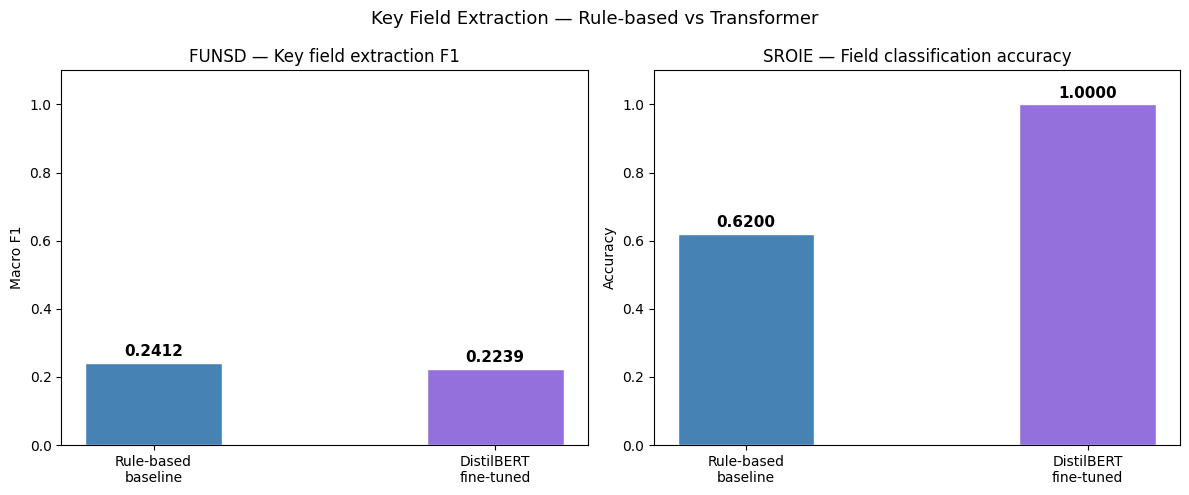

Comparison chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#FUNSD comparison
methods_funsd = ['Rule-based\nbaseline', 'DistilBERT\nfine-tuned']
f1_funsd      = [baseline_f1, best_f1]
colors        = ['steelblue', 'mediumpurple']

axes[0].bar(methods_funsd, f1_funsd, color=colors, edgecolor='white', width=0.4)
axes[0].set_title("FUNSD — Key field extraction F1")
axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(f1_funsd):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center',
                 fontsize=11, fontweight='bold')

#SROIE comparison
methods_sroie = ['Rule-based\nbaseline', 'DistilBERT\nfine-tuned']
acc_sroie     = [
    np.mean(list(rule_sroie_results.values())),
    best_sroie_acc
]

axes[1].bar(methods_sroie, acc_sroie, color=colors, edgecolor='white', width=0.4)
axes[1].set_title("SROIE — Field classification accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(acc_sroie):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center',
                 fontsize=11, fontweight='bold')

plt.suptitle("Key Field Extraction — Rule-based vs Transformer", fontsize=13)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/key_field_comparison.png", dpi=150)
plt.show()
print("Comparison chart is saved.")